# LLM-based program repair on Defects4J: qwen3.6:35b vs gpt-oss:120b

Comparative analysis of the **post-audit campaign** over the **854 active
Defects4J bugs**: one `Experiment.py` run per bug and per model, identical
configuration (`--include-test-code --include-test-log --include-issue
--fixcheck --fixcheck-prefixes 10`, temperature 0.0, `--max-tokens 32768`,
`--context-length 131072`, FixCheck budget 1800 s per trigger class). See
`README.md` for the method, `docs/campaign.md` for the protocol and the
verdict-of-record rule, and `docs/audit-2026-09.md` for the defects found in
the first campaign and fixed before this one. That first campaign
(`results/old/9-Sep`) is used only in §4.5, as a second draw of the same models.

**How to read the outcome flags.** Each one is a stricter bar than the
last, so every stage is a subset of the previous one:

- `applied` — the generated diff could be applied to the checkout at all;
- `triggers_fixed` — the bug's trigger tests pass after the patch;
- `fixed` — the patched sources compile, `triggers_fixed` holds, and the patch
  introduces no new failing test.

**Caveats stated up front**

- **One run per bug.** Every rate is a single sample of a non-deterministic
  process, even at temperature 0. §4.4 tests the paired difference between the
  models; §4.5 measures how much a single model's verdicts move between two
  runs, which is the scale any per-bug claim has to be read against.
- **Budget-truncated generations** (§2.1) are recorded as not fixed, never
  silently: whether they count as the model failing is a judgement call, and
  §4.4 reports the comparison both ways.
- **Time is not a usable cost measure** in this campaign: part of it generated
  on the wrong physical GPU or on CPU (audit §1.12). Section 5 uses tokens.
- **FixCheck** verdicts are advisory single samples; a `suspicious: false` is
  weak evidence and many are *vacuous*. Section 6 separates them, and §6.3
  checks every flagged patch against the developer's fix.

## 1. Setup and data loading

One tidy DataFrame, one row per `(model, project, bug_id)`. The loader is
`summarize_campaign.collect_project()` — the same code the CLI aggregator uses,
so the notebook and `summarize_campaign.py` cannot disagree about the schema.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Repo root = nearest ancestor holding results/ (works from analysis/ and from
# a headless nbconvert run alike).
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "results").is_dir())
sys.path.insert(0, str(REPO))

from d4j.defects4j_bugs import PROJECT_BUG_COUNTS, TOTAL_ACTIVE_BUGS
from summarize_campaign import collect_project

MODELS = ["qwen3.6:35b", "gpt-oss:120b"]
# Color follows the entity in every figure (categorical slots 1 and 2 of the
# validated palette; CVD-safe pair).
MODEL_COLORS = {"qwen3.6:35b": "#2a78d6", "gpt-oss:120b": "#eb6834"}

rows = []
for model in MODELS:
    root = REPO / "results" / model
    for project in PROJECT_BUG_COUNTS:
        for record in collect_project(str(root), project):
            rows.append({"model": model, **record})
df = pd.DataFrame(rows)
df["bug"] = df["project"] + "-" + df["bug_id"]

print(f"{len(df)} rows ({TOTAL_ACTIVE_BUGS} active bugs x {len(MODELS)} models = "
      f"{TOTAL_ACTIVE_BUGS * len(MODELS)} possible)")
df.head(3)


1708 rows (854 active bugs x 2 models = 1708 possible)


,model,project,bug_id,status,exit_code,seconds,has_result,applied,compiled_after,triggers_fixed,...,fixcheck_suspicious,verdict_source,post_fix_tests,generation_status,included_issue,issue_status,llm_seconds,input_tokens,output_tokens,bug
0,qwen3.6:35b,Chart,1,ok,0.0,207.5,True,True,True,True,...,False,run,NaN,ok,False,unusable,30.456,19059.0,2541.0,Chart-1
1,qwen3.6:35b,Chart,10,ok,0.0,46.8,True,True,False,False,...,False,run,NaN,ok,False,empty,17.007,2052.0,2471.0,Chart-10
2,qwen3.6:35b,Chart,11,ok,0.0,261.0,True,True,True,True,...,False,run,NaN,ok,False,unusable,17.909,7914.0,2394.0,Chart-11


In [2]:
# Recessive, consistent chart defaults: y-grid only, no chart junk.
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": "#e6e4dd", "grid.linewidth": 0.8,
    "axes.grid.axis": "y",
    "font.size": 10,
})


## 2. Data quality and completeness

Every bug has a verdict for both models. The two `timed_out` rows are not
missing results: they are the two verdicts of record reconstructed under the
first-verdict rule (gpt-oss Closure 74, whose patch made the test suite hang;
qwen Math 13, whose first run passed every test before FixCheck hung) — see
§2.1 and `docs/campaign.md`, "The verdict of record".

In [3]:
completeness = (
    df.assign(completed=df["has_result"])
      .groupby("model")
      .agg(attempted=("bug", "count"),
           completed=("completed", "sum"),
           errored=("status", lambda s: (s == "error").sum()),
           timed_out=("status", lambda s: (s == "timeout").sum()))
)
completeness["never_attempted"] = TOTAL_ACTIVE_BUGS - completeness["attempted"]
completeness


,attempted,completed,errored,timed_out,never_attempted
model,,,,,
gpt-oss:120b,854,854,0,1,0
qwen3.6:35b,854,854,0,1,0


In [4]:
# Which projects are missing bugs, per model (completed vs the project's total)?
per_project = (
    df[df["has_result"]]
    .groupby(["model", "project"])["bug"].count().unstack(0)
    .reindex(PROJECT_BUG_COUNTS).fillna(0).astype(int)
)
per_project["active_bugs"] = pd.Series(PROJECT_BUG_COUNTS)
incomplete = per_project[(per_project[MODELS].lt(per_project["active_bugs"], axis=0)).any(axis=1)]
incomplete


model,gpt-oss:120b,qwen3.6:35b,active_bugs
project,,,


**Prompt-leakage guard.** Issue reports are cut at the first `Comment:` line
before reaching the prompt (`strip_issue_comments`), because the maintainers'
thread routinely discusses the fix. This cell re-verifies that **no prompt in
either tree** contains the thread, so the guarantee survives any future
regeneration of the data.


In [5]:
import re

comment_marker = re.compile(r"^Comment:\s*$", re.M)
leaked = []
for model in MODELS:
    for prompt_path in (REPO / "results" / model).glob("*/Bug_*/prompt.txt"):
        text = prompt_path.read_text(encoding="utf-8", errors="replace")
        start = text.find("[ORIGINAL ISSUE REPORT]")
        if start == -1:
            continue
        end = text.find("\n[", start + 5)
        if comment_marker.search(text[start:end if end != -1 else None]):
            leaked.append(prompt_path)
assert not leaked, f"{len(leaked)} prompts contain the issue comment thread: {leaked[:5]}"
print("OK: no prompt carries the issue comment thread.")


OK: no prompt carries the issue comment thread.


### 2.1 How each generation ended, and where each verdict comes from

`generation_status` says why an empty patch is empty. `truncated` and
`context_exhausted` mean the model spent its token budget — for a reasoning
model, typically on its chain of thought — before writing an answer. Those runs
are recorded as not fixed, and they are *listed* here rather than folded into
the failures, because they measure the budget as much as the model
(`docs/generation-budget.md`).

`verdict_source` is `run` for an ordinary result, and names the evidence for
the few verdicts restored or reconstructed under the verdict-of-record rule.

In [6]:
TRUNCATED = {"truncated", "context_exhausted"}
truncated_bugs = set(df.loc[df["generation_status"].isin(TRUNCATED), "bug"])

completed_rows = df[df["has_result"]]
generation = (completed_rows
              .assign(generation_status=completed_rows["generation_status"].fillna("not recorded"))
              .pivot_table(index="generation_status", columns="model", values="bug",
                           aggfunc="count", fill_value=0)
              .reindex(columns=MODELS, fill_value=0))
display(generation)

# Runs whose verdict or FixCheck result needs a footnote in any write-up.
special = completed_rows[
    (completed_rows["verdict_source"] != "run")
    | (completed_rows["post_fix_tests"] == "did_not_terminate")
    | completed_rows["fixcheck_degraded"]
][["model", "bug", "fixed", "verdict_source", "post_fix_tests", "fixcheck_degraded"]]
special.sort_values(["model", "bug"])

model,qwen3.6:35b,gpt-oss:120b
generation_status,,
context_exhausted,1,0
not recorded,1,1
ok,822,853
truncated,30,0


,model,bug,fixed,verdict_source,post_fix_tests,fixcheck_degraded
1066,gpt-oss:120b,Closure-74,False,job_log+reapply,did_not_terminate,False
1161,gpt-oss:120b,Compress-3,True,run,NaN,True
1172,gpt-oss:120b,Compress-4,True,run,NaN,True
1182,gpt-oss:120b,Compress-6,True,run,NaN,True
1183,gpt-oss:120b,Compress-7,True,run,NaN,True
695,qwen3.6:35b,Math-13,True,job_log,NaN,False


### 2.2 Patches that applied but did not compile

Applying cleanly and compiling are different bars, and a sizeable slice of the
generated patches clears the first but not the second: `git apply` only needs
the context lines to match, while `javac` needs the result to be valid Java.
These runs count as attempted and completed, never as fixed.

In [7]:
completed_runs = df[df["has_result"]].assign(
    applied_but_not_compiled=lambda t: t["applied"] & ~t["compiled_after"]
)
compile_stats = (
    completed_runs
    .groupby("model")
    .agg(applied=("applied", "sum"),
         did_not_compile=("applied_but_not_compiled", "sum"))
    .reindex(MODELS)
)
compile_stats["% of applied"] = (
    compile_stats["did_not_compile"] / compile_stats["applied"] * 100
).round(1)
compile_stats


,applied,did_not_compile,% of applied
model,,,
qwen3.6:35b,796,116,14.6
gpt-oss:120b,799,104,13.0


They concentrate in the largest, most complex projects, where a patch has more
surrounding API to get wrong:


In [8]:
not_compiled = df[df["has_result"] & df["applied"] & ~df["compiled_after"]]
(not_compiled.groupby(["project", "model"])["bug"].count()
 .unstack("model").reindex(columns=MODELS).fillna(0).astype(int)
 .assign(total=lambda t: t.sum(axis=1)).sort_values("total", ascending=False).head(8))


model,qwen3.6:35b,gpt-oss:120b,total
project,,,
Closure,39,38,77
JacksonDatabind,23,15,38
Jsoup,12,9,21
Mockito,9,8,17
Math,6,3,9
Collections,5,3,8
Cli,5,3,8
Time,5,3,8


## 3. Paired dataset

The model comparison uses only bugs with a completed run in **both** trees:
same denominator, fair bug-for-bug comparison, and it enables the agreement
matrix of section 4. Everything excluded here was already accounted for in
section 2.


In [9]:
completed = df[df["has_result"]]
counts = completed.groupby("bug")["model"].nunique()
paired_bugs = set(counts[counts == len(MODELS)].index)
paired = completed[completed["bug"].isin(paired_bugs)].copy()

for model in MODELS:
    lost = completed[completed["model"] == model]["bug"].nunique() - len(paired_bugs)
    print(f"{model}: {lost} completed bug(s) dropped by pairing")
print(f"paired comparison set: {len(paired_bugs)} bugs")


qwen3.6:35b: 0 completed bug(s) dropped by pairing
gpt-oss:120b: 0 completed bug(s) dropped by pairing
paired comparison set: 854 bugs


## 4. Core comparison

### 4.1 Patch outcomes, stage by stage

How far does each model get, over the same paired bugs? Each stage is a subset
of the previous one.


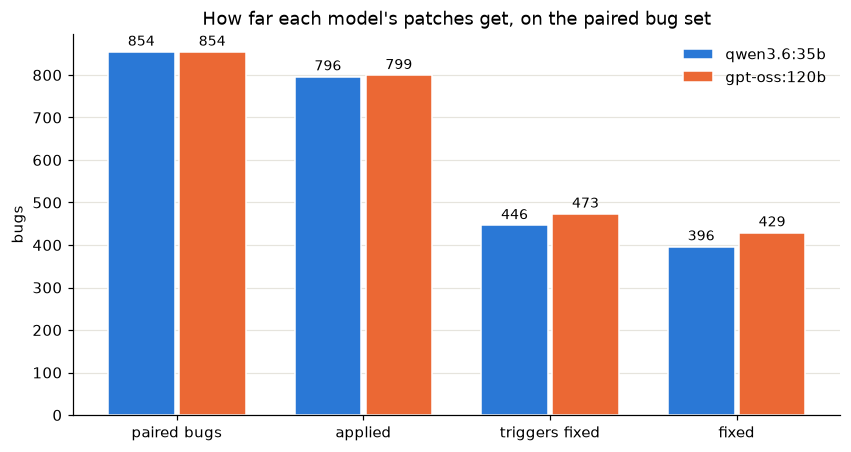

,applied %,triggers_fixed %,fixed %
model,,,
qwen3.6:35b,93.2,52.2,46.4
gpt-oss:120b,93.6,55.4,50.2


In [10]:
stages = ["applied", "triggers_fixed", "fixed"]
stage_counts = paired.groupby("model")[stages].sum().reindex(MODELS)
stage_counts.insert(0, "paired_bugs", len(paired_bugs))

fig, ax = plt.subplots()
x = range(len(stage_counts.columns))
width = 0.38
for i, model in enumerate(MODELS):
    values = stage_counts.loc[model]
    bars = ax.bar([p + (i - 0.5) * width for p in x], values, width * 0.94,
                  color=MODEL_COLORS[model], label=model, edgecolor="white")
    ax.bar_label(bars, fmt="%d", padding=2, fontsize=9)
ax.set_xticks(list(x), ["paired bugs", "applied", "triggers fixed", "fixed"])
ax.set_ylabel("bugs")
ax.set_title("How far each model's patches get, on the paired bug set")
ax.legend(frameon=False)
plt.show()

stage_rates = (stage_counts[stages].div(len(paired_bugs)) * 100).round(1)
stage_rates.columns = [c + " %" for c in stages]
stage_rates


The `triggers_fixed` → `fixed` drop is patches that satisfy the trigger tests
but **break something else** (`new_failures`); the count per model:


In [11]:
regressions = paired[paired["triggers_fixed"] & ~paired["fixed"]]
regressions.groupby("model")["bug"].count().rename("plausible but regressing").to_frame()


,plausible but regressing
model,
gpt-oss:120b,44
qwen3.6:35b,50


### 4.2 Fixed rate per project

Same paired set, split by project. Project size varies wildly (JacksonXml has
6 bugs, Closure 174), so the *rate* is plotted and the project's paired size is
in the axis label.


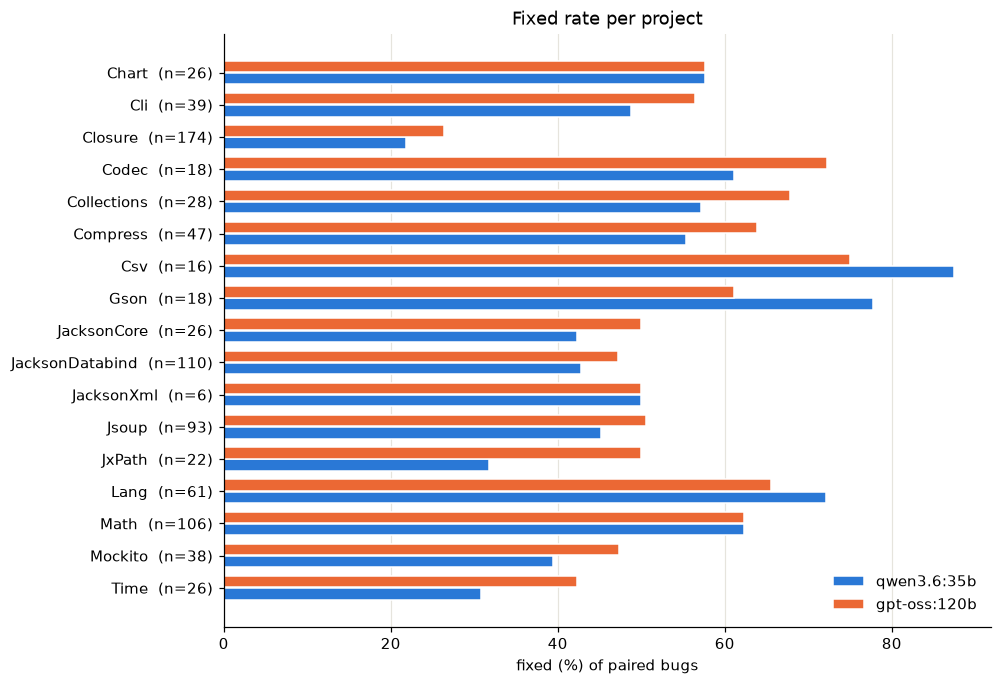

In [12]:
by_project = (
    paired.groupby(["project", "model"])["fixed"].agg(["sum", "count"]).reset_index()
)
by_project["rate"] = by_project["sum"] / by_project["count"] * 100
rate = by_project.pivot(index="project", columns="model", values="rate").reindex(PROJECT_BUG_COUNTS)
sizes = by_project.pivot(index="project", columns="model", values="count").reindex(PROJECT_BUG_COUNTS)

fig, ax = plt.subplots(figsize=(9, 7))
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
y = range(len(rate))
height = 0.38
for i, model in enumerate(MODELS):
    ax.barh([p + (0.5 - i) * height for p in y], rate[model], height * 0.94,
            color=MODEL_COLORS[model], label=model, edgecolor="white")
ax.set_yticks(list(y), [f"{p}  (n={int(sizes.loc[p].iloc[0])})" for p in rate.index])
ax.invert_yaxis()
ax.set_xlabel("fixed (%) of paired bugs")
ax.set_title("Fixed rate per project")
ax.legend(frameon=False, loc="lower right")
plt.show()


### 4.3 Agreement matrix

Where do the models agree, and which bugs does exactly one of them fix? The
"only one" cells are the natural candidates for qualitative deep-dives — but
read §4.5 first: a sizeable share of each model's own verdicts change between
two runs, so membership of these lists is a property of one draw, not proof
that one model can fix a bug and the other cannot.

In [13]:
wide = paired.pivot(index="bug", columns="model", values="fixed")
q, g = MODELS
matrix = pd.DataFrame(
    [[int((wide[q] & wide[g]).sum()), int((wide[q] & ~wide[g]).sum())],
     [int((~wide[q] & wide[g]).sum()), int((~wide[q] & ~wide[g]).sum())]],
    index=pd.Index([f"{q}: fixed", f"{q}: not fixed"]),
    columns=pd.Index([f"{g}: fixed", f"{g}: not fixed"]),
)
matrix


,gpt-oss:120b: fixed,gpt-oss:120b: not fixed
qwen3.6:35b: fixed,310,86
qwen3.6:35b: not fixed,119,339


In [14]:
only_q = sorted(wide[wide[q] & ~wide[g]].index)
only_g = sorted(wide[~wide[q] & wide[g]].index)
print(f"fixed ONLY by {q} ({len(only_q)}):\n  " + ", ".join(only_q) + "\n")
print(f"fixed ONLY by {g} ({len(only_g)}):\n  " + ", ".join(only_g))


fixed ONLY by qwen3.6:35b (86):
  Chart-25, Chart-4, Cli-24, Cli-3, Cli-9, Closure-123, Closure-13, Closure-130, Closure-15, Closure-160, Closure-17, Closure-18, Closure-27, Closure-3, Closure-78, Closure-85, Closure-9, Codec-7, Collections-12, Compress-19, Compress-24, Compress-32, Csv-10, Csv-16, Csv-3, Gson-11, Gson-12, Gson-13, Gson-2, Gson-4, JacksonCore-13, JacksonCore-25, JacksonDatabind-101, JacksonDatabind-103, JacksonDatabind-110, JacksonDatabind-112, JacksonDatabind-14, JacksonDatabind-15, JacksonDatabind-22, JacksonDatabind-35, JacksonDatabind-47, JacksonDatabind-5, JacksonDatabind-53, JacksonDatabind-54, JacksonDatabind-58, JacksonDatabind-78, JacksonDatabind-79, Jsoup-10, Jsoup-17, Jsoup-18, Jsoup-23, Jsoup-24, Jsoup-32, Jsoup-44, Jsoup-48, Jsoup-53, Jsoup-55, Jsoup-60, Jsoup-79, Jsoup-87, Lang-24, Lang-34, Lang-35, Lang-36, Lang-4, Lang-43, Lang-44, Lang-53, Lang-58, Math-106, Math-19, Math-42, Math-49, Math-59, Math-62, Math-64, Math-65, Math-78, Math-79, Math-93, Mocki

### 4.4 Is the difference larger than chance?

Both models ran on the *same* bugs, so the right test is paired: McNemar's
exact test uses only the bugs where the two disagree — the off-diagonal cells
of §4.3 — and asks whether one side wins more often than a fair coin allows.

The budget-truncated qwen3.6:35b generations of §2.1 count as not fixed in the
main comparison. Since that is a judgement call, the test is repeated with
those bugs removed for **both** models.

In [15]:
from math import comb


def mcnemar_exact(b, c):
    """Two-sided exact McNemar p-value from the two discordant counts."""
    n, k = b + c, min(b, c)
    return min(1.0, 2 * sum(comb(n, i) for i in range(k + 1)) / 2 ** n)


def paired_test(frame):
    w = frame.pivot(index="bug", columns="model", values="fixed").astype(bool)
    q, g = MODELS
    only_g, only_q = int((w[g] & ~w[q]).sum()), int((~w[g] & w[q]).sum())
    return {
        "bugs": len(w),
        f"fixed {q}": int(w[q].sum()),
        f"fixed {g}": int(w[g].sum()),
        "gap (pts)": round(100 * (w[g].mean() - w[q].mean()), 1),
        f"only {g}": only_g,
        f"only {q}": only_q,
        "McNemar p": round(mcnemar_exact(only_g, only_q), 3),
    }


significance = pd.DataFrame({
    "all paired bugs": paired_test(paired),
    "without budget-truncated bugs": paired_test(paired[~paired["bug"].isin(truncated_bugs)]),
}).T
mcnemar_p = float(significance.loc["all paired bugs", "McNemar p"])
significance

,bugs,fixed qwen3.6:35b,fixed gpt-oss:120b,gap (pts),only gpt-oss:120b,only qwen3.6:35b,McNemar p
all paired bugs,854.0,396.0,429.0,3.9,119.0,86.0,0.025
without budget-truncated bugs,823.0,396.0,419.0,2.8,109.0,86.0,0.115


In [16]:
# The reading, computed rather than typed, so it cannot go stale.
for label, row in significance.iterrows():
    verdict = "significant" if row["McNemar p"] < 0.05 else "NOT significant"
    print(f"{label:32} gap {row['gap (pts)']:+.1f} pts, p = {row['McNemar p']:.3f} -> {verdict} at 0.05")

all paired bugs                  gap +3.9 pts, p = 0.025 -> significant at 0.05
without budget-truncated bugs    gap +2.8 pts, p = 0.115 -> NOT significant at 0.05


### 4.5 How reproducible is a single run?

The same two models ran over the same 854 bugs twice: the archived campaign
and this one. That is not a clean replication — the second run fixed the
evaluation defects, raised the token budget and isolated the GPUs — but for
**gpt-oss:120b**, which never came near the old budget, it is close to one.
Comparing the two answers what a single-run benchmark cannot: how much of a
per-bug verdict belongs to the bug, and how much to the draw.

In [17]:
ARCHIVE = REPO / "results" / "old" / "9-Sep"
archived = pd.DataFrame([
    {"model": model, "bug": f"{project}-{record['bug_id']}", "fixed": record["fixed"]}
    for model in MODELS
    for project in PROJECT_BUG_COUNTS
    for record in collect_project(str(ARCHIVE / model), project)
    if record["has_result"]
])
both = (df[df["has_result"]][["model", "bug", "fixed"]]
        .merge(archived, on=["model", "bug"], suffixes=("_now", "_archived")))

repro = {}
for model in MODELS:
    g = both[both["model"] == model]
    now, before = g["fixed_now"].astype(bool), g["fixed_archived"].astype(bool)
    repro[model] = {
        "bugs in both campaigns": len(g),
        "fixed, archived": int(before.sum()),
        "fixed, this campaign": int(now.sum()),
        "verdict changed": int((now != before).sum()),
        "not fixed -> fixed": int((now & ~before).sum()),
        "fixed -> not fixed": int((~now & before).sum()),
    }
repro = pd.DataFrame(repro).T
repro["verdict changed %"] = (100 * repro["verdict changed"] / repro["bugs in both campaigns"]).round(1)
repro

,bugs in both campaigns,"fixed, archived","fixed, this campaign",verdict changed,not fixed -> fixed,fixed -> not fixed,verdict changed %
qwen3.6:35b,852,402,395,163,78,85,19.1
gpt-oss:120b,848,426,426,162,81,81,19.1


In [18]:
for model, row in repro.iterrows():
    net = int(row["not fixed -> fixed"] - row["fixed -> not fixed"])
    print(f"{model:13} {row['verdict changed %']:.1f}% of its per-bug verdicts changed between "
          f"the two runs, for a net change of {net:+d} fixes.")
print("\nAggregate rates are stable; individual verdicts are not. A claim about a single bug "
      "rests on one draw of a process that changes its answer this often.")

qwen3.6:35b   19.1% of its per-bug verdicts changed between the two runs, for a net change of -7 fixes.
gpt-oss:120b  19.1% of its per-bug verdicts changed between the two runs, for a net change of +0 fixes.

Aggregate rates are stable; individual verdicts are not. A claim about a single bug rests on one draw of a process that changes its answer this often.


## 5. Cost: tokens

Tokens are the only usable cost unit in this campaign. Wall-clock seconds are
deliberately not shown: part of the campaign generated on the wrong physical
GPU (46 GB L40S cards spilling a 62 GB model) or on CPU before the device
mapping was fixed (audit §1.12), so `seconds` and `llm_seconds` measure the
placement as much as the model.

For a reasoning model, output tokens include the chain of thought, which is why
qwen3.6:35b spends several times more per bug.

In [19]:
cost = paired.dropna(subset=["output_tokens"])
summary_cost = cost.groupby("model").agg(
    runs_with_usage=("bug", "count"),
    median_input_tokens=("input_tokens", "median"),
    median_output_tokens=("output_tokens", "median"),
).round(1).reindex(MODELS)
summary_cost

,runs_with_usage,median_input_tokens,median_output_tokens
model,,,
qwen3.6:35b,853,8887.0,5898.0
gpt-oss:120b,853,8057.0,1672.0


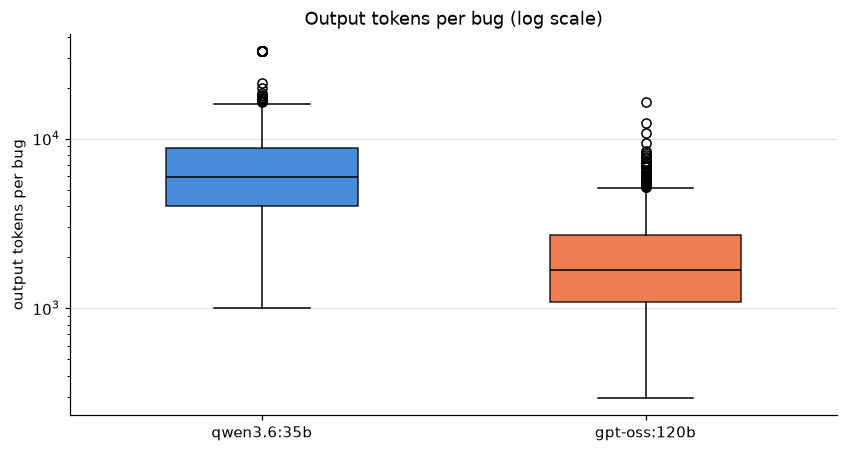

In [20]:
fig, ax = plt.subplots()
data = [cost.loc[cost["model"] == m, "output_tokens"] for m in MODELS]
parts = ax.boxplot(data, tick_labels=MODELS, patch_artist=True, widths=0.5,
                   medianprops={"color": "black"})
for patch, model in zip(parts["boxes"], MODELS):
    patch.set_facecolor(MODEL_COLORS[model]); patch.set_alpha(0.85)
ax.set_ylabel("output tokens per bug")
ax.set_yscale("log")
ax.set_title("Output tokens per bug (log scale)")
plt.show()


**Cost per success** — median output tokens spent per bug, next to each
model's fixed count, gives a rough fixes-per-token economy:


In [21]:
# Over the runs that recorded token usage (reconstructed verdicts have none).
per_success = cost.groupby("model").agg(
    fixed=("fixed", "sum"),
    total_output_tokens=("output_tokens", "sum"),
).reindex(MODELS)
per_success["output_tokens_per_fix"] = (
    per_success["total_output_tokens"] / per_success["fixed"]
).round(0)
per_success

,fixed,total_output_tokens,output_tokens_per_fix
model,,,
qwen3.6:35b,395,6378089.0,16147.0
gpt-oss:120b,429,1805083.0,4208.0


## 6. FixCheck overfitting check

FixCheck's verdict never changes `fixed` — it is advisory. Four things matter
when reading it, and they are easy to conflate:

- **Only plausible patches are checked.** FixCheck runs when the patch applied,
  compiled and passes the trigger tests. (In the archived campaign it was also
  invoked on 203 patches that never compiled; that defect is fixed.)
- **Ran is not analysed.** A verdict with `fixcheck_analyzed == 0` is
  **vacuous**: nothing could be mutated, or FixCheck crashed or ran out of its
  1800 s budget, so "not suspicious" carries no information. §6.1 breaks them
  down; `docs/fixcheck-vacuous-verdicts.md` explains the mechanisms.
- **No measurement** is a third bucket: FixCheck results known to be unsound
  (its assertion generator timed out while the model ran on the wrong GPU) or
  missing (a reconstructed verdict). They are kept on disk, and counted here as
  neither a verdict nor a vacuous one.
- **Even a real `suspicious: false` is weak evidence** — single sample, known
  detection limits (`docs/fixcheck-verdict-limitations.md`).

Everything in this section is computed over the paired plausible patches.

In [22]:
# Population: paired bugs whose patch applied, compiled, and fixed the triggers.
plausible = paired[paired["triggers_fixed"]]
fixcheck = plausible.groupby("model").agg(
    plausible_patches=("bug", "count"),
    # Called at all vs got far enough to analyse anything. `fixcheck_analyzed`
    # is None (not 0) when FixCheck never ran, so count explicitly rather than
    # letting a missing measurement fall into the "vacuous" bucket.
    fixcheck_invoked=("fixcheck_invoked", "sum"),
    fixcheck_ran=("fixcheck_ran", "sum"),
    real_verdicts=("fixcheck_analyzed", lambda s: (s.fillna(-1) > 0).sum()),
    vacuous_verdicts=("fixcheck_analyzed", lambda s: (s.fillna(-1) == 0).sum()),
    no_measurement=("fixcheck_analyzed", lambda s: s.isna().sum()),
    suspicious=("fixcheck_suspicious", "sum"),
).reindex(MODELS)

assert (fixcheck["real_verdicts"] + fixcheck["vacuous_verdicts"]
        + fixcheck["no_measurement"] == fixcheck["plausible_patches"]).all(), \
    "every plausible patch must fall in exactly one verdict bucket"
fixcheck


,plausible_patches,fixcheck_invoked,fixcheck_ran,real_verdicts,vacuous_verdicts,no_measurement,suspicious
model,,,,,,,
qwen3.6:35b,446,446,445,337,108,1,2
gpt-oss:120b,473,473,469,350,119,4,2


In [23]:
suspicious_bugs = paired[paired["fixcheck_suspicious"]]
suspicious_bugs[["model", "bug", "fixed", "fixcheck_analyzed"]]


,model,bug,fixed,fixcheck_analyzed
54,qwen3.6:35b,Cli-35,True,1.0
725,qwen3.6:35b,Math-40,False,1.0
908,gpt-oss:120b,Cli-35,True,1.0
1314,gpt-oss:120b,JacksonDatabind-6,False,1.0


### 6.1 Why so many verdicts are vacuous

A vacuous verdict is not always a legitimate skip. It splits into things that
are by design and things that are failures:

- **skips** — the trigger method has no literal to mutate outside its
  assertions, or it is inherited so FixCheck cannot see its source;
- **crashes** — FixCheck died without writing `report.csv`: a
  `NullPointerException` when a generated prefix fails to compile, or
  `No locals of type <T>` when our `inputs-class` heuristic picks a type
  FixCheck cannot find;
- **budget** — FixCheck was stopped at its 1800 s budget (role-blind mutation of
  an `int` can make a variation effectively unbounded).

Counted over exactly the `vacuous_verdicts` of §6, reading each run's own
`fixcheck.log`.

In [24]:
import json
from collections import Counter


def vacuous_reason(model, project, bug_id):
    """Why a plausible patch got no FixCheck evidence."""
    base = REPO / "results" / model / project / f"Bug_{bug_id}"
    block = json.loads((base / "result.json").read_text()).get("fixcheck") or {}
    if block.get("timed_out_test_classes"):
        return "budget: stopped at the FixCheck time limit"
    errors = [r.get("error") or "" for r in block.get("per_test_class", [])]
    if any("report.csv missing" in e for e in errors):
        text = "".join(p.read_text(encoding="utf-8", errors="replace")
                       for p in base.glob("fixcheck/*/fixcheck.log"))
        if "No locals of type" in text:
            return "crash: inputs-class heuristic mismatch"
        if "NullPointerException" in text:
            return "crash: a prefix did not compile (upstream NPE)"
        return "crash: other"
    if any("no mutable literal" in e for e in errors):
        return "skip: no mutable literal outside assertions"
    if any("not declared in this class" in e for e in errors):
        return "skip: inherited trigger method"
    return "skip: other"


vacuous_rows = plausible[plausible["fixcheck_analyzed"].fillna(-1) == 0]
reasons = Counter(vacuous_reason(r.model, r.project, r.bug_id)
                  for r in vacuous_rows.itertuples())
vacuous = pd.Series(reasons).sort_values(ascending=False).rename("runs").to_frame()
vacuous["share %"] = (vacuous["runs"] / vacuous["runs"].sum() * 100).round(1)
assert vacuous["runs"].sum() == int(fixcheck["vacuous_verdicts"].sum()), \
    "the breakdown must cover exactly the vacuous verdicts of section 6"
vacuous

,runs,share %
skip: no mutable literal outside assertions,85,37.4
crash: inputs-class heuristic mismatch,58,25.6
crash: a prefix did not compile (upstream NPE),48,21.1
crash: other,20,8.8
skip: inherited trigger method,14,6.2
budget: stopped at the FixCheck time limit,2,0.9


### 6.2 Why so few patches are flagged

The verdict is **not** "nothing failed". Most analysed runs *do* have a failing
variation — what filters them out is the similarity score, and almost the whole
distribution sits far below the 0.8 threshold. The flagged patches are the tail
of a continuous distribution, not a separated cluster.

In [25]:
analysed = paired[paired["fixcheck_analyzed"] > 0].copy()
with_failures = analysed[analysed["failing_prefixes"] > 0]
print(f"analysed runs:                {len(analysed)}")
print(f"  with >=1 failing variation: {len(with_failures)} "
      f"({100 * len(with_failures) / len(analysed):.0f}%)")
print(f"  flagged suspicious:         {int(analysed['fixcheck_suspicious'].sum())}")


analysed runs:                687
  with >=1 failing variation: 581 (85%)
  flagged suspicious:         4


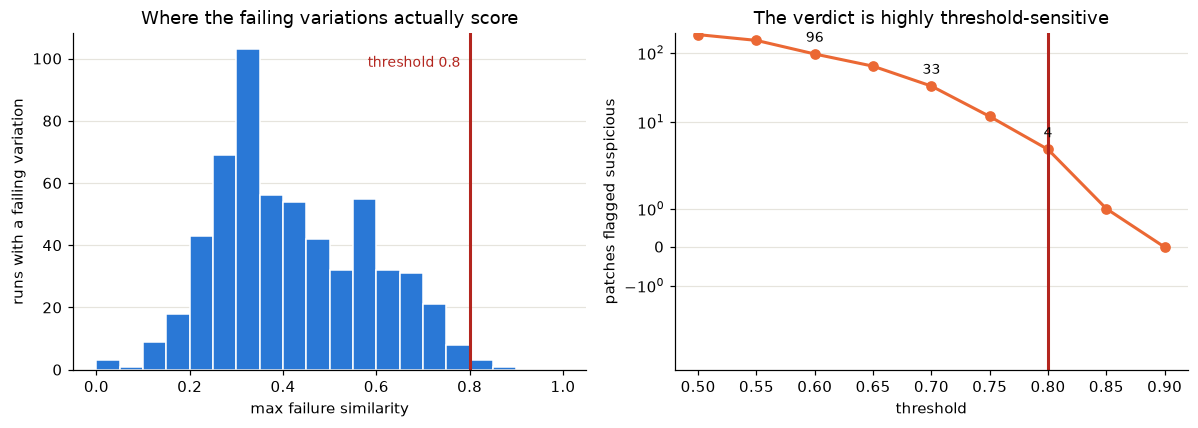

threshold,0.50,0.55,0.60,0.65,0.70,0.75,0.80,0.85,0.90
flagged,183,151,96,64,33,12,4,1,0


In [26]:
scores = with_failures["max_failure_similarity"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.hist(scores, bins=20, range=(0, 1), color=MODEL_COLORS[MODELS[0]], edgecolor="white")
ax1.axvline(0.8, color="#b3251e", linewidth=2)
ax1.annotate("threshold 0.8", xy=(0.8, ax1.get_ylim()[1] * 0.9), xytext=(-6, 0),
             textcoords="offset points", ha="right", color="#b3251e", fontsize=9)
ax1.set_xlabel("max failure similarity")
ax1.set_ylabel("runs with a failing variation")
ax1.set_title("Where the failing variations actually score")

thresholds = [round(t, 2) for t in [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]]
flagged = [int((scores >= t).sum()) for t in thresholds]
ax2.plot(thresholds, flagged, marker="o", color=MODEL_COLORS[MODELS[1]], linewidth=2)
ax2.axvline(0.8, color="#b3251e", linewidth=2)
ax2.set_xlabel("threshold")
ax2.set_ylabel("patches flagged suspicious")
ax2.set_title("The verdict is highly threshold-sensitive")
ax2.set_yscale("symlog")
for t, n in zip(thresholds, flagged):
    if t in (0.6, 0.7, 0.8):
        ax2.annotate(f"{n}", xy=(t, n), xytext=(0, 8), textcoords="offset points",
                     ha="center", fontsize=9)
plt.tight_layout()
plt.show()

pd.DataFrame({"threshold": thresholds, "flagged": flagged}).set_index("threshold").T


### 6.3 What the flagged patches actually show

Each flagged variation was **run against the Defects4J developer-fixed version
of the bug** (`<id>f`). If it fails there the same way, the mutated input was
invalid and the flag is a false positive; if it passes there, the model's patch
is genuinely incomplete. None of the four flags survives:

**Cli 35** (both models, similarity 0.812). FixCheck mutated `"--prefix"` into
`"--pref"`, which *is* ambiguous between the options `prefix` and
`prefixplusplus`. The developer's fix throws the same `AmbiguousOptionException`
on it: the mutation turned "exact match, must succeed" into "real ambiguity,
must fail". **False positive**, for both models.

**Math 40** (qwen3.6:35b, similarity 0.848). FixCheck mutated the solver's
*maximum evaluation count* down to 5, and the developer's fix throws the same
`TooManyEvaluationsException`. **False positive** — on a patch already rejected
anyway (`fixed=False`, three regressions).

**JacksonDatabind 6** (gpt-oss:120b, similarity 0.855). The matching trace does
not come from the mutated trigger method at all. FixCheck copies the whole test
class, and the failure is in `test8601DateTimeNoMilliSecs`, a sibling test run
on its original data — and one of the patch's two known regressions
(`new_failures`). The mutated trigger methods themselves behave like the
developer's fix. The flag re-detects what `fixed=False` already records; it
adds no information.

All four are crashes (`assertion_failing == 0`), and the last one is a
limitation not documented before: **regressions in sibling tests leak into the
similarity score**, because the whole class is re-run.

**Bottom line for reporting.** Across every plausible paired patch, FixCheck
produced four flags and none carries information beyond `fixed`.
`fixcheck_suspicious` must not be presented as an overfitting *rate*; on this
configuration the check has no measurable detection power. See
[docs/fixcheck-verdict-limitations.md](../docs/fixcheck-verdict-limitations.md).

## 7. Does having the issue report help?

Fixed rate split by `issue_status`: `available` means the reporter's original
text was in the prompt; `unusable`/`empty` mean the prompt carried no issue
(SourceForge scrapes to a navigation menu; some bugs have no tracker URL).

**This is not causal.** Chart contributes *zero* issues (all 26 bugs), so
project difficulty and issue availability are confounded — read this as
descriptive only.


In [27]:
issue_effect = (
    paired.assign(has_issue=paired["issue_status"].eq("available"))
    .groupby(["model", "has_issue"])["fixed"].agg(["mean", "count"])
)
issue_effect["mean"] = (issue_effect["mean"] * 100).round(1)
issue_effect.rename(columns={"mean": "fixed %", "count": "bugs"})


fixed %  bugs
model        has_issue               
gpt-oss:120b False         56.1    41
             True          49.9   813
qwen3.6:35b  False         48.8    41
             True          46.2   813

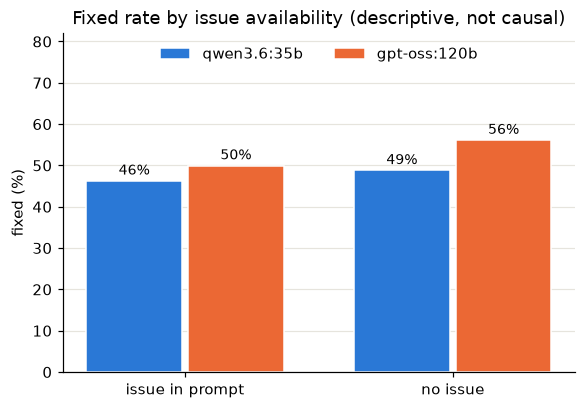

In [28]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = ["issue in prompt", "no issue"]
x = range(len(labels))
width = 0.38
for i, model in enumerate(MODELS):
    sub = paired[paired["model"] == model]
    vals = [
        sub[sub["issue_status"] == "available"]["fixed"].mean() * 100,
        sub[sub["issue_status"] != "available"]["fixed"].mean() * 100,
    ]
    bars = ax.bar([p + (i - 0.5) * width for p in x], vals, width * 0.94,
                  color=MODEL_COLORS[model], label=model, edgecolor="white")
    ax.bar_label(bars, fmt="%.0f%%", padding=2, fontsize=9)
ax.set_xticks(list(x), labels)
ax.set_ylabel("fixed (%)")
ax.set_ylim(0, 82)     # headroom so the legend never collides with bar labels
ax.set_title("Fixed rate by issue availability (descriptive, not causal)")
ax.legend(frameon=False, loc="upper center", ncols=2)
plt.show()


## 8. Headline summary

The numbers a write-up would quote, in one table.


In [29]:
# Every row states the population it is counted over. Three coexist in this
# notebook -- all 854 attempted bugs, the runs that completed, and the paired
# set -- and rows from different ones sitting side by side is how a number gets
# read against the wrong denominator.
headline = pd.DataFrame({
    model: {
        "attempted (of 854)": int(completeness.loc[model, "attempted"]),
        "completed runs (of 854)": int(completeness.loc[model, "completed"]),
        f"paired bugs (n={len(paired_bugs)})": len(paired_bugs),
        "applied (of paired)": int(stage_counts.loc[model, "applied"]),
        "triggers fixed (of paired)": int(stage_counts.loc[model, "triggers_fixed"]),
        "fixed (of paired)": int(stage_counts.loc[model, "fixed"]),
        "fixed % (of paired)": round(
            stage_counts.loc[model, "fixed"] / len(paired_bugs) * 100, 1),
        "budget-truncated generations (of paired)": int(
            paired[(paired["model"] == model)
                   & paired["generation_status"].isin(TRUNCATED)].shape[0]),
        "plausible but regressing (of paired)": int(
            regressions.groupby("model")["bug"].count().get(model, 0)),
        "fixcheck suspicious (of plausible)": int(fixcheck.loc[model, "suspicious"]),
        "verdict changed vs archived run (%)": float(repro.loc[model, "verdict changed %"]),
        "median output tokens (of paired w/ usage)":
            summary_cost.loc[model, "median_output_tokens"],
    }
    for model in MODELS
})
print(f"Paired difference: McNemar exact p = {mcnemar_p:.3f} "
      f"(without budget-truncated bugs: p = "
      f"{significance.loc['without budget-truncated bugs', 'McNemar p']:.3f})")
headline

Paired difference: McNemar exact p = 0.025 (without budget-truncated bugs: p = 0.115)


,qwen3.6:35b,gpt-oss:120b
attempted (of 854),854.0,854.0
completed runs (of 854),854.0,854.0
paired bugs (n=854),854.0,854.0
applied (of paired),796.0,799.0
triggers fixed (of paired),446.0,473.0
fixed (of paired),396.0,429.0
fixed % (of paired),46.4,50.2
budget-truncated generations (of paired),31.0,0.0
plausible but regressing (of paired),50.0,44.0
fixcheck suspicious (of plausible),2.0,2.0


---
*Extension points:* more draws per bug — two campaigns already show a fifth of
the per-bug verdicts moving between runs, so three or more would turn
per-bug claims into rates; a qualitative review of the "only one model" lists
of §4.3 against that noise; diff-size analysis from `fix.diff`; and a FixCheck
variant that mutates only the trigger method, to remove the sibling-test
leakage found in §6.3.